In [1098]:
import os
import sys
from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [1099]:
model_u, model_k = build_models(
    device=device,
    hidden_layers=4,
    hidden_units=125,
    activation=nn.Tanh(),
) 

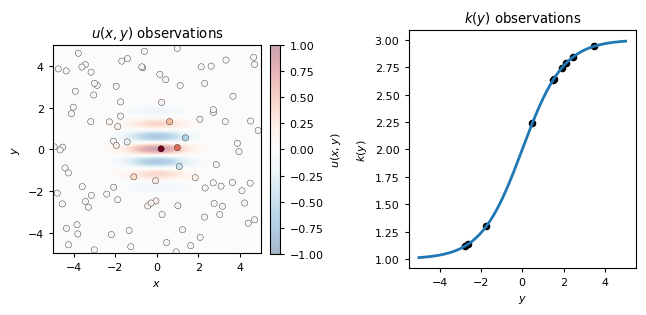

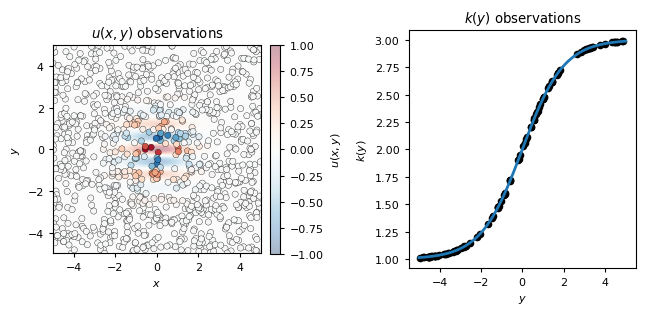

In [1100]:
# Training data
(
    X_obs_train,
    U_obs_train,
    X_obs_k_train,
    K_obs_train,
    X_pde_train,
    F_pde_train,
    *_,
) = generate_dataset_inf(
    n_obs_u=100,
    n_obs_k=10,
    n_pde=1000,
    plot=True,
    device=device,
)

# Test data
(
    X_obs_test,
    U_obs_test,
    X_obs_k_test,
    K_obs_test,
    X_pde_test,
    F_pde_test,
    *_,
) = generate_dataset_inf(
    n_obs_u=100*10,
    n_obs_k=10*10,
    n_pde=1000*10,
    plot=True,
    device=device,
)

In [1101]:
history = train_dual_network(
    model_u,
    model_k,
    X_obs_train,
    U_obs_train,
    X_obs_k_train,
    K_obs_train,
    X_pde_train,
    F_pde_train,
    X_obs_test,
    U_obs_test,
    X_obs_k_test,
    K_obs_test,
    X_pde_test,
    F_pde_test,
    adam_lr=1e-4,
    adam_iters=3000,
    lbfgs_iters=3000,
    adaptive_weights=True,
    verbose=True,
    regularization=True
)


Training with Adam
V      = [ 0.166  0.666 45.544]
R      = [0.    0.011 1.   ]
ratio  = 274.11
lambda = [ 1.    1.11 11.  ]
Adam     0 | Total=5.019e+02 | ObsU=1.662e-01 | ObsK=6.661e-01 | PDE=4.554e+01 | Ratio=274.11
Adam   100 | Total=2.353e+02 | ObsU=2.432e-01 | ObsK=9.865e-01 | PDE=2.127e+01 | Ratio=160.09
Adam   200 | Total=1.837e+02 | ObsU=1.867e-01 | ObsK=1.037e+00 | PDE=1.658e+01 | Ratio=113.78
Adam   300 | Total=1.133e+02 | ObsU=9.699e-02 | ObsK=1.057e+00 | PDE=1.019e+01 | Ratio=112.56
Adam   400 | Total=5.587e+01 | ObsU=1.635e-01 | ObsK=1.064e+00 | PDE=4.957e+00 | Ratio=106.19
Adam   500 | Total=1.356e+01 | ObsU=1.351e-01 | ObsK=1.065e+00 | PDE=1.113e+00 | Ratio=77.46
Adam   600 | Total=8.964e+00 | ObsU=1.735e-02 | ObsK=1.062e+00 | PDE=7.062e-01 | Ratio=74.92
Adam   700 | Total=6.976e+00 | ObsU=5.967e-02 | ObsK=1.058e+00 | PDE=5.220e-01 | Ratio=73.16
Adam   800 | Total=5.646e+00 | ObsU=8.468e-02 | ObsK=1.052e+00 | PDE=3.994e-01 | Ratio=68.96
Adam   900 | Total=4.684e+00 | O

Relative L2 error (u): 6.514e-02
Relative L2 error (k): 1.985e-03


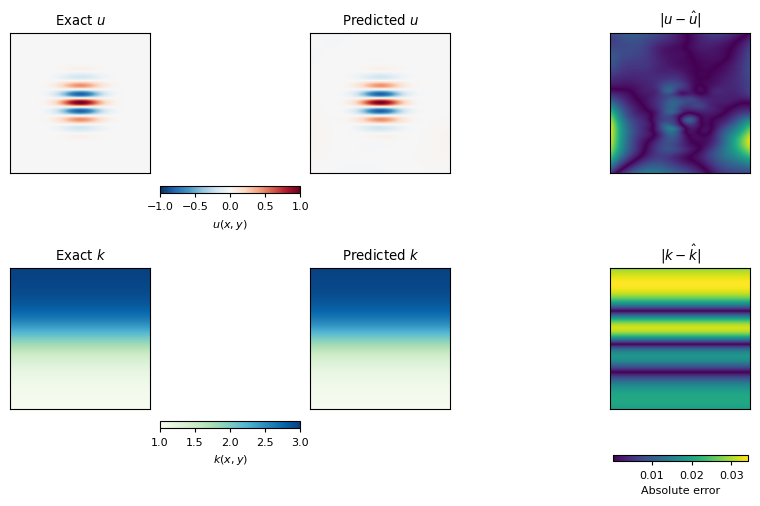

In [1105]:
err_u, err_k = evaluate_model_inf(
    model_u,
    model_k,
    analytical_solution_inf,
    coefficient_inf,
    device=device,
    save_results=False,
    verbose=True,
    plot=True
)

In [1106]:
with open("results/history_fixed_no_reg.pkl", "rb") as f:
    history_fixed_no_reg = pickle.load(f)

with open("results/history_fixed_reg.pkl", "rb") as f:
    history_fixed_reg = pickle.load(f)

with open("results/history_adaptive_reg.pkl", "rb") as f:
    history_adaptive_reg = pickle.load(f)

with open("results/history_adaptive_no_reg.pkl", "rb") as f:
    history_adaptive_no_reg = pickle.load(f)

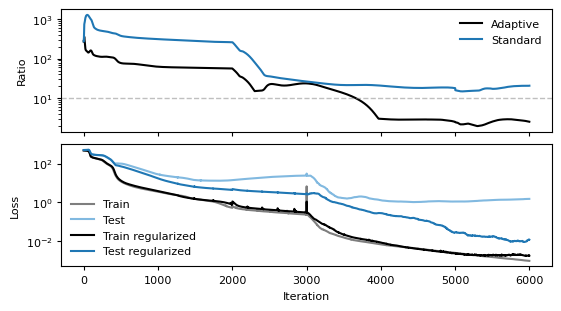

In [1109]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    2, 1,
    figsize=(5.5, 3),
    sharex=True,
    constrained_layout=True,
)

# --------------------------------------------------
# Top panel: Ratio
# --------------------------------------------------

ax[0].plot(
    history_adaptive_reg["ratio"],
    label="Adaptive",
    color="black",
)

ax[0].plot(
    history_fixed_reg["ratio"],
    label="Standard",
    color="#1f77b4",
)

ax[0].axhline(
    y=10.0,
    color="gray",
    linestyle="--",
    lw=1,
    alpha=0.5,
)

ax[0].set_ylabel("Ratio")
ax[0].set_yscale("log")
ax[0].legend(frameon=False)

# --------------------------------------------------
# Bottom panel: Loss
# --------------------------------------------------

ax[1].plot(
    history_adaptive_no_reg["total_no_reg"],
    label="Train",
    color="#7E7E7E",
)

ax[1].plot(
    history_adaptive_no_reg["total_no_reg_test"],
    label="Test",
    color="#81b9e0",
)

ax[1].plot(
    history_adaptive_reg["total_no_reg"],
    label="Train regularized",
    color="black",
)

ax[1].plot(
    history_adaptive_reg["total_no_reg_test"],
    label="Test regularized",
    color="#1f77b4",
)

ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Loss")
ax[1].set_yscale("log")
ax[1].legend(frameon=False)

plt.show()